In [1]:
LOG_DIR = '../../experiments/current/'


In [2]:
# Parameters
LOG_DIR = "../../experiments/current/"


In [3]:
import os
import matplotlib.pyplot as plt
import yaml
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

import sys
!{sys.executable} -m pip install --upgrade kaleido



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [4]:
mode_colors = {
    'marche': 'cyan',
    'voiture': 'red',
    'velo': 'purple',
    'transports_collectifs': 'green'
}

mode_order = ['marche', 'voiture', 'velo', 'transports_collectifs']

def _img_path(title, ext="png"):
    name = "".join(c if c.isalnum() or c in "-_" else "_" for c in title)
    img_dir = os.path.join(LOG_DIR, "images/stats")
    os.makedirs(img_dir, exist_ok=True)
    return os.path.join(img_dir, f"{name}.{ext}")

def pie_graph(subset,reference_cerema, title):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    colors = [mode_colors.get(label, 'gray') for label in mode_order]

    # For ax1
    counts1 = subset["Plus rapide"].value_counts().reindex(mode_order).fillna(0)
    if (counts1.isna().any()):
        print("Warning: Some modes in 'Plus rapide' are not in the predefined mode order."+str(counts1))
    ax1.pie(counts1, labels=mode_order, colors=colors, autopct='%1.1f%%')
    ax1.set_title("Plus rapide")

    # For ax2
    counts2 = subset["Mode de transport Choisi"].value_counts().reindex(mode_order).fillna(0)
    ax2.pie(counts2, labels=mode_order, colors=colors, autopct='%1.1f%%')
    ax2.set_title("Agent LLM")

    # For ax3
    if "autres_modes" in reference_cerema:
        reference_cerema.pop("autres_modes")

    reference_series = pd.Series(reference_cerema, name="Percentage")
    reference_series = reference_series.reindex(mode_order).fillna(0)
    
    ax3.pie(reference_series, labels=mode_order, colors=colors, autopct='%1.1f%%')
    ax3.set_title("Enquête mobilité certifiée Cerema")

    fig.suptitle(title)

    plt.tight_layout()
    fig.savefig(_img_path(title), bbox_inches='tight', dpi=150)
    plt.show()


def bar_graph(subset, reference_cerema, title, x_name):

    if x_name not in subset.columns:
        print(f"Error: The specified x_name '{x_name}' is not a column in the dataset.")
        print(f"Available columns: {subset.columns.tolist()}")
        return

    reference_order = list(reference_cerema.keys())
    if set(subset[x_name].unique()) != set(reference_order):
        print(f"Warning: The unique values in the dataset for '{x_name}' do not match the keys in the reference data.")
        print(f"Dataset values: {subset[x_name].unique().tolist()}")
        print(f"Reference keys: {reference_order}")
        
    # 1. Préparation des données
    df_fast = subset.groupby([x_name, "Plus rapide"]).size().reset_index(name='count')
    df_llm = subset.groupby([x_name, "Mode de transport Choisi"]).size().reset_index(name='count')
    
    df_cerema = pd.DataFrame.from_dict(reference_cerema, orient="index").reset_index()
    df_cerema.rename(columns={"index": x_name}, inplace=True)

    df_cerema = df_cerema.reset_index().melt(
        id_vars=x_name,
        var_name='Mode de transport Choisi', 
        value_name='count'
    )

    for df in [df_fast, df_llm, df_cerema]:
        df[x_name] = pd.Categorical(df[x_name], categories=reference_order, ordered=True)
        df.sort_values(x_name, inplace=True)

    fig = make_subplots(rows=1, cols=3, subplot_titles=("Plus rapide", "Agent LLM", "Enquête Cerema"))

    # Fonction utilitaire pour ajouter les traces avec couleurs et labels
    def add_mode_traces(fig, df, mode_col, val_col, column, show_legend_start):
        for i, mode in enumerate(mode_order):
            data = df[df[mode_col] == mode]
            # On n'affiche la légende que pour le premier subplot pour éviter les doublons
            show_v_legend = True if (show_legend_start and i < len(mode_order)) else False
            
            fig.add_trace(
                go.Bar(
                    x=data[x_name],
                    y=data[val_col],
                    name=mode,
                    marker_color=mode_colors.get(mode, 'gray'),
                    legendgroup=mode,
                    showlegend=show_v_legend,
                    # Configuration du texte en %
                    texttemplate='%{text:.1f}%',
                    textposition='inside',
                    # Calcul manuel du texte (requis car barnorm est au niveau layout)
                    text=[(v / df[df[x_name] == x]["count" if "count" in df else "Value"].sum()) * 100 
                          for x, v in zip(data[x_name], data[val_col])]
                ),
                row=1, col=column
            )

    # Ajout des traces pour les 3 subplots
    add_mode_traces(fig, df_fast, "Plus rapide", "count", 1, True)
    add_mode_traces(fig, df_llm, "Mode de transport Choisi", "count", 2, False)
    add_mode_traces(fig, df_cerema, "Mode de transport Choisi", "count", 3, False)

    # Configuration globale
    fig.update_layout(
        title_text=title,
        barmode="relative",
        barnorm="percent",
        height=600,
        width=1300,
        bargap=0.5,
        legend_title="Modes",
        yaxis_title="Pourcentage (%)",
    )

    fig.update_xaxes(
        type='category', 
        categoryorder='array', 
        categoryarray=reference_order,
        showgrid=False
    )

    fig.write_image(_img_path(title), scale=2)
    fig.show()


In [5]:
with open("../data/population/cerema_values.yaml", "r") as f:
    cerema = yaml.safe_load(f)

# Exemple : Accéder aux parts modales de Toulouse
print(cerema["parts_modales_2023"]["global"])

def print_cerema_parts_modales(cerema,key0):
    total = 0
    for key, value in cerema[key0].items():
        if isinstance(cerema[key0][key], dict):
            print_cerema_parts_modales(cerema[key0],key)
        else:
            total = total + value
    if (total != 100) and (total > 0):
        print(f"Warning: Total for {key0} is {total}%, expected 100%.")

print_cerema_parts_modales(cerema,"parts_modales_2023")

{'voiture': 55, 'marche': 26, 'transports_collectifs': 12, 'velo': 4, 'autres_modes': 3}


In [6]:
#moves = pd.read_csv('../../experiments/current/moves.csv')
moves = pd.read_csv(LOG_DIR + 'moves.csv')

#moves = pd.read_csv('../../experiments/2026-05-07_12_23/moves.csv')
moves = moves[moves["Distance parcourue"]>0]

# Normalisation des noms de modes de transport
moves.replace({'Marche':"marche", 'Voiture Privée':"voiture", 'Vélo':"velo", 'Bus':"transports_collectifs", 'Transports_collectifs':"transports_collectifs"}, inplace=True)

# Normalisation des catégories d'occupation
moves.replace({'Travail à plein temps':"actif_temps_plein", "Scolaire (jusqu'au Bac)":"scolaire", "Chômeur/recherche d'emploi":"chomeur_recherche_emploi", 'Personne au foyer':"personne_au_foyer", 'Travail à temps partiel':"actif_temps_partiel", 'Étudiant':"etudiant"}, inplace=True)


# Dataset values: ['Achats', 'Travail', 'leisure', 'Etude', 'home']
# Reference keys: ['domicile_travail', 'domicile_etudes', 'domicile_achats', 'domicile_accompagnement']²
moves.replace({'Achats':"achats", 'Travail':"travail", 'leisure':"loisirs", 'Etude':"etudes"}, inplace=True)

# Dataset values: ['1ere couronne', '2eme couronne', 'Toulouse']
# Reference keys: ['Toulouse', '1ere_couronne', '2eme_couronne', '3eme_couronne']
moves.replace({'1ere couronne':"1ere_couronne", '2eme couronne':"2eme_couronne"}, inplace=True)

display(moves.describe())
moves.head()

,Trajet,Âge,Type de logement,Distance parcourue,Température,Météo Température (°C),Météo Précipitations (mm),Retard planification (s),Temps simulé
count,3668.000000,3668.000000,0.0,3668.00000,3668.0,3668.000000,3668.000000,3668.0,3.668000e+03
mean,1907.448201,37.843239,NaN,9.26051,0.0,10.187568,0.169684,0.0,1.774202e+09
std,1103.220968,22.466039,NaN,10.71802,0.0,4.408972,0.379380,0.0,3.671639e+05
min,8.000000,5.000000,NaN,0.08000,0.0,2.000000,0.000000,0.0,1.773637e+09
25%,950.750000,20.000000,NaN,1.77000,0.0,7.000000,0.000000,0.0,1.773867e+09
50%,1903.500000,34.000000,NaN,4.73000,0.0,10.000000,0.000000,0.0,1.774165e+09
75%,2864.250000,56.000000,NaN,14.08000,0.0,14.000000,0.200000,0.0,1.774546e+09
max,3817.000000,88.000000,NaN,51.10000,0.0,17.000000,1.300000,0.0,1.774862e+09


,Référence,Trajet,ID Trajet,Mode de transport Choisi,Plus rapide,Modes proposés au LLM,Lieu de résidence,Genre,Âge,Occupation principale,...,Filtre de perception,Traits de personnalité,Météo Température (°C),Météo Condition,Météo Précipitations (mm),Raisonnement,Retard planification (s),Heure de calcul,Temps simulé,Heure de départ
7,2026-06-10_18_54,8,83261229-c00f-417c-be4c-002cdb439170,velo,velo,velo,1ere_couronne,Femme,88,Retraité,...,False,False,3.0,Ciel dégagé/Ensoleillé,0.0,"Un seul itinéraire disponible, sélection autom...",0,2026-06-10T16:57:41+00:00,1773637201,2026-03-16 11:52:40
8,2026-06-10_18_54,9,fe427d8a-7310-4948-8b46-bef7996cbe0e,voiture,voiture,voiture,2eme_couronne,Femme,57,actif_temps_plein,...,False,False,3.0,Ciel dégagé/Ensoleillé,0.0,"Un seul itinéraire disponible, sélection autom...",0,2026-06-10T16:57:41+00:00,1773637201,2026-03-16 07:20:12
9,2026-06-10_18_54,10,56b2212b-c985-4690-8a0c-39b807c5b657,voiture,voiture,voiture,2eme_couronne,Homme,10,scolaire,...,False,False,3.0,Ciel dégagé/Ensoleillé,0.0,"Un seul itinéraire disponible, sélection autom...",0,2026-06-10T16:57:41+00:00,1773637201,2026-03-16 08:34:41
10,2026-06-10_18_54,11,7b76e786-1e5e-48d5-a61a-f328860d620a,voiture,voiture,voiture,2eme_couronne,Femme,16,scolaire,...,False,False,3.0,Ciel dégagé/Ensoleillé,0.0,"Un seul itinéraire disponible, sélection autom...",0,2026-06-10T16:57:41+00:00,1773637201,2026-03-16 08:25:19
11,2026-06-10_18_54,12,6bdcdd12-a351-4499-9b4e-62e55067c3b6,voiture,voiture,voiture,2eme_couronne,Femme,39,personne_au_foyer,...,False,False,3.0,Ciel dégagé/Ensoleillé,0.0,"Un seul itinéraire disponible, sélection autom...",0,2026-06-10T16:57:42+00:00,1773637201,2026-03-16 06:14:55


In [7]:
bins = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 131]
labels = ['5-9', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-130']

moves['Age_cat'] = pd.cut(moves['Âge'], bins=bins, labels=labels, right=False)

In [8]:
print(mode_order)


['marche', 'voiture', 'velo', 'transports_collectifs']


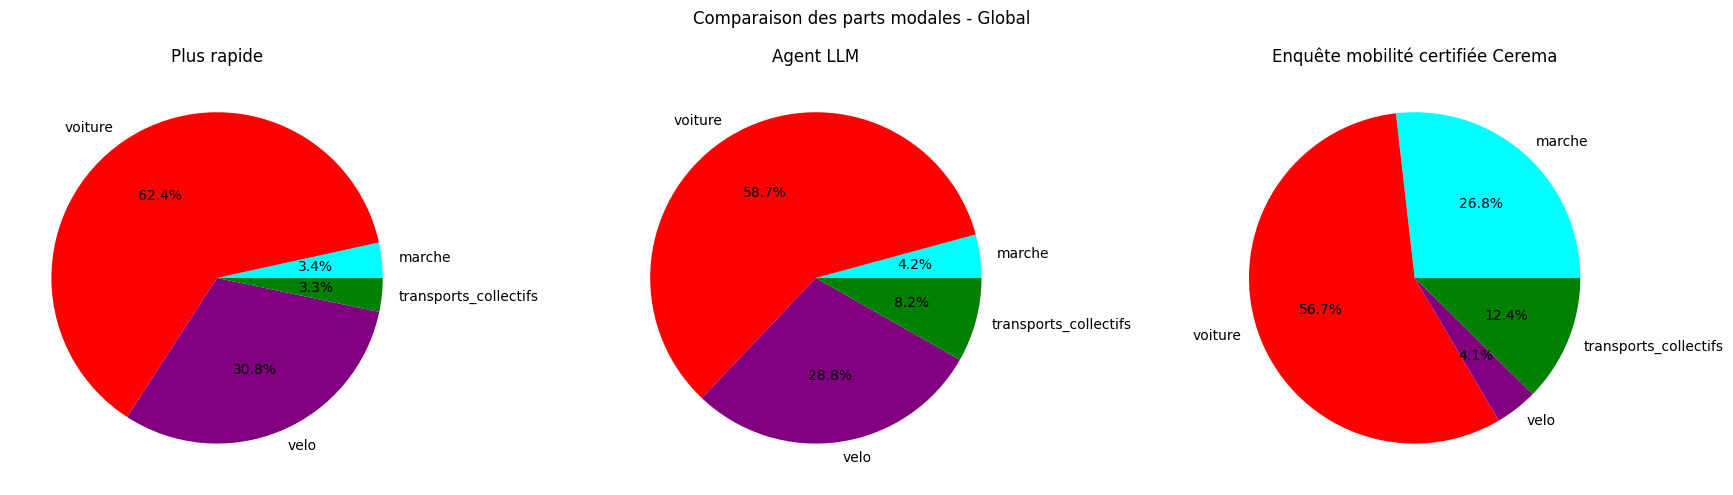

In [9]:
pie_graph(moves, cerema["parts_modales_2023"]["global"], "Comparaison des parts modales - Global")

In [10]:
bar_graph(moves, cerema["parts_modales_2023"]["genre"], "Comparaison des parts modales par genre", x_name="Genre")


In [11]:
bar_graph(moves, cerema["parts_modales_2023"]["Age"], "Comparaison des parts modales par âge", x_name="Age_cat")


In [12]:
bar_graph(moves, cerema["parts_modales_2023"]["lieu_residence"], "Comparaison des parts modales par lieux de résidence", x_name="Lieu de résidence")

Dataset values: ['1ere_couronne', '2eme_couronne', 'Toulouse']
Reference keys: ['Toulouse', '1ere_couronne', '2eme_couronne', '3eme_couronne']


In [13]:
bar_graph(moves, cerema["parts_modales_2023"]["occupation"], "Comparaison des parts modales selon l'occupation principale", x_name="Occupation principale")

In [14]:
#bar_graph(moves, cerema["parts_modales_2023"]["type_logement"], "Comparaison des parts modales des Hommes", x_name="Type de logement")

In [15]:
bar_graph(moves, cerema["parts_modales_2023"]["motif_deplacement"], "Comparaison des parts modales selon le motif de déplacement", x_name="Motifs de déplacement")

Dataset values: ['achats', 'travail', 'home', 'etudes', 'loisirs', 'other']
Reference keys: ['travail', 'etudes', 'achats', 'accompagnement']


/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_30021/2783383109.py:77: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df[x_name] = pd.Categorical(df[x_name], categories=reference_order, ordered=True)
/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_30021/2783383109.py:77: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df[x_name] = pd.Categorical(df[x_name], categories=reference_order, ordered=True)
/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_30021/2783383109.py:101: RuntimeWarning: divide by zero encountered in scalar divide
  text=[(v / df[df[x_name] == x]["count" if "count" in df else "Value"].sum()) * 100


In [16]:
moves["rayon"] = pd.cut(moves["Distance parcourue"], bins=[0, 1, 2, 5, 10, 20, 50, float('inf')], labels=["0-1km", "1-2km", "2-5km", "5-10km", "10-20km", "20-50km", "50km+"])
bar_graph(moves, cerema["parts_modales_2023"]["distance"], "Comparaison des parts modales selon le rayon de déplacement", x_name="rayon")

Dataset values: ['20-50km', '50km+', '0-1km', '2-5km', '5-10km', '1-2km', '10-20km']
Reference keys: ['0-1km', '1-2km', '2-5km', '5-10km', '10-20km', '20-50km', 'plus_50km']


/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_30021/2783383109.py:77: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df[x_name] = pd.Categorical(df[x_name], categories=reference_order, ordered=True)
/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_30021/2783383109.py:77: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df[x_name] = pd.Categorical(df[x_name], categories=reference_order, ordered=True)
/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_30021/2783383109.py:101: RuntimeWarning: divide by zero encountered in scalar divide
  text=[(v / df[df[x_name] == x]["count" if "count" in df else "Value"].sum()) * 100
